<a href="https://colab.research.google.com/github/Guederas/CECS-427---Group-Project/blob/main/Assignment1_427_Group2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CECS 427 - Assignment 2

## Resources (Required Reading)

Research the NetworkX package:

* NetworkX Basics: https://networkx.org/documentation/stable/reference/introduction.html#networkx-basics

* NetworkX Tutorial: https://networkx.org/documentation/stable/tutorial.html

---

## Part A — NetworkX Practice with the Karate Club Graph

You will start with the Zachary Karate Club friendship network used in lecture.

### **Using NetworkX**

1. Load the Karate Club Graph

    * https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html

2. Draw the graph (using matplotlib)

3. Display basic network information:

    * number of nodes

    * number of edges

    * whether the graph is connected

    * average degree
    
    * density

4. Display:

    * Neighbors of node `0`

    * The distance (shortest path length) from node `0` to all other nodes

    * The shortest path from node `16` to node `23`



In [2]:
# 1. Loading the Karate Club Graph
import networkx as nx

G = nx.karate_club_graph()

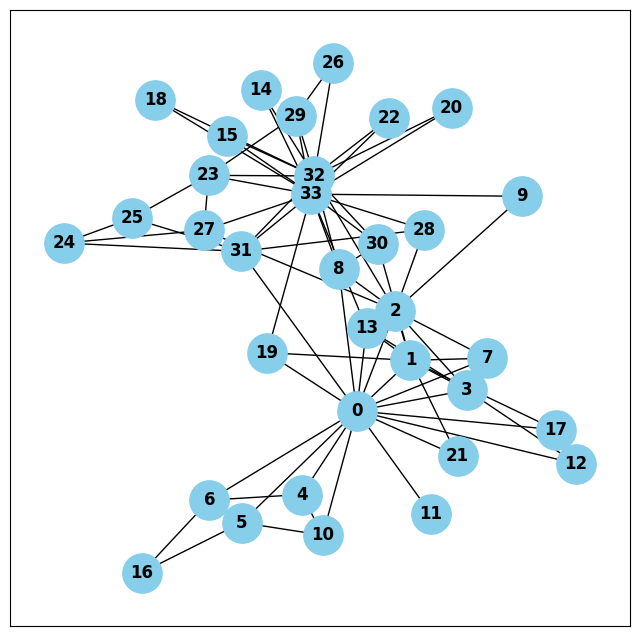

In [3]:
# 2. Draw the graph using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
nx.draw_networkx(G, with_labels=True, node_color='skyblue', node_size=800, font_weight='bold')
plt.show()

In [4]:
# 3. Displaying network information
num_of_nodes = nx.number_of_nodes(G)
num_of_edges = nx.number_of_edges(G)

avg_degree = round((2*num_of_edges)/num_of_nodes, 2)

d = round(nx.density(G),2)

print(f"Number of nodes: {num_of_nodes}.")
print(f"Number of edges: {num_of_edges}.")
if nx.is_connected(G): print ("The graph is connected.")
else: print("The graph is not connected.")
print(f"Average degree: {avg_degree}.")
print(f"Density: {d}.")


Number of nodes: 34.
Number of edges: 78.
The graph is connected.
Average degree: 4.59.
Density: 0.14.


In [5]:
# 4. Displaying neighbors of 0
print(f"Neighbors of node 0: {list(nx.all_neighbors(G, 0))}")

# Distance from 0 to all other nodes
result = nx.single_source_shortest_path_length(G, source=0)
print(f"Distance from node 0 to all other nodes: {result}")

# Shortest path from node 16 to 23
print(f"Distance from node 16 to node 23: {nx.shortest_path_length(G, source = 16, target = 23)}")


Neighbors of node 0: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Distance from node 0 to all other nodes: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 10: 1, 11: 1, 12: 1, 13: 1, 17: 1, 19: 1, 21: 1, 31: 1, 30: 2, 9: 2, 27: 2, 28: 2, 32: 2, 16: 2, 33: 2, 24: 2, 25: 2, 23: 3, 14: 3, 15: 3, 18: 3, 20: 3, 22: 3, 29: 3, 26: 3}
Distance from node 16 to node 23: 5


---

## Part B — Implement BFS from Scratch

*You must implement BFS without calling `nx.bfs_*` or `nx.shortest_path*` inside your BFS implementation.*

<br>

### **Implement BFS**

* Use a queue (e.g., `collections.deque`)

* `dist[source] = 0`

* For each reachable node `v`, `dist[v]` must be the shortest-path distance from source

* `paths[source]` should be `[source]`

* For each reachable node `v != source`, `paths[v]` should be a valid shortest path list

In [6]:
from collections import deque

def bfs(G, source):
    """
    Returns:
      dist: dict[node] -> int
      paths: dict[node] -> list of nodes representing a shortest path from source to node
    """
    dist = {source: 0}
    paths = {source: [source]}
    queue = deque([source])

    while queue:
      current = queue.popleft() # return the element at index 0 of the queue

      neighbors = sorted(G.neighbors(current)) # find all sorted neighbors of the current node

      for n in neighbors:
        if n not in dist:
          dist[n] = dist[current] + 1 # increment the distance
          paths[n] = paths[current] + [n]
          queue.append(n)

    return dist, paths


# G1 = nx.Graph()

# G1.add_edges_from([
#     ("A", "B"),
#     ("A", "C"),
#     ("B", "D"),
#     ("C", "D"),
#     ("D", "E")
# ])

# dist, paths = bfs(G1, "A")

# print("Distances:", dist)
# print("Paths:", paths)



### **BFS Layers**

Implement a second function `bfs_layers(G, source)`:

* `layers[d]` is a sorted list

* `layers[0]` must contain only `[source]`

* Must be based on your BFS results (recommended: reuse `dist`)

In [7]:
def bfs_layers(G, source):
    """
    Returns:
      layers: dict[int] -> sorted list of nodes at distance d from source
    """
    layers = {0: [source]}

    dist, paths = bfs(G, source)

    for i in range(1, len(dist) - 1):
      queue = [node for node, distance in dist.items() if distance == i]
      layers[i] = queue

    return layers

# l = bfs_layers(G1, "A")
# print(l)

### **Test your BFS on Karate Graph**

* Run your BFS from source node `0` on the karate graph.

* Compare your BFS distances and shortest path against NetworkX. Print confirmation that they match.
    
    * The distance (shortest path length) from node 0 to all other nodes

    * The shortest path from node 16 to node 23

* Display BFS layers

In [8]:
# BFS from source = 0
dist, paths = bfs(G, 0)

print("Distance: ", dist)
print("Paths:", paths)

# Compare to BFS from networkX
d = nx.single_source_shortest_path_length(G, source=0)
print("Compare BFS with networkX result: ", d == dist)

# Shortest path from node 16 to 23
dist2, paths2 = bfs(G, source=16) # using BFS algorithm
x = nx.single_source_shortest_path_length(G, source=16) # using NetworkX
print ("BFS distances from node 16 to 23: ",dist2[23])
print ("NetworkX distances from node 16 to 23: ",x[23])

# Display BFS layers
layers = bfs_layers(G, 0)
print("BFS layers: ", layers)


Distance:  {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 10: 1, 11: 1, 12: 1, 13: 1, 17: 1, 19: 1, 21: 1, 31: 1, 30: 2, 9: 2, 27: 2, 28: 2, 32: 2, 16: 2, 33: 2, 24: 2, 25: 2, 23: 3, 14: 3, 15: 3, 18: 3, 20: 3, 22: 3, 29: 3, 26: 3}
Paths: {0: [0], 1: [0, 1], 2: [0, 2], 3: [0, 3], 4: [0, 4], 5: [0, 5], 6: [0, 6], 7: [0, 7], 8: [0, 8], 10: [0, 10], 11: [0, 11], 12: [0, 12], 13: [0, 13], 17: [0, 17], 19: [0, 19], 21: [0, 21], 31: [0, 31], 30: [0, 1, 30], 9: [0, 2, 9], 27: [0, 2, 27], 28: [0, 2, 28], 32: [0, 2, 32], 16: [0, 5, 16], 33: [0, 8, 33], 24: [0, 31, 24], 25: [0, 31, 25], 23: [0, 2, 27, 23], 14: [0, 2, 32, 14], 15: [0, 2, 32, 15], 18: [0, 2, 32, 18], 20: [0, 2, 32, 20], 22: [0, 2, 32, 22], 29: [0, 2, 32, 29], 26: [0, 8, 33, 26]}
Compare BFS with networkX result:  True
BFS distances from node 16 to 23:  5
NetworkX distances from node 16 to 23:  5
BFS layers:  {0: [0], 1: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31], 2: [30, 9, 27, 28, 32, 16, 33, 24, 25], 3: [23

---

## Part C — Erdős–Rényi Random Graphs

Implement and analyze Erdős–Rényi random graphs using only the definition and formula introduced in lecture.

* You may use NetworkX to create an empty graph and add edges.

* Do not use `nx.gnp_random_graph()` or other NetworkX random-graph generators.

<br>

### **Generate Random Graphs with `c = 0.4`, `c = 0.6`, and `c = 1.5`**

* Let `n` be number of nodes in the karate graph

* For each given constant `c`, compute `p`

Generate **three** random graphs for each value of `c`:

1. For each graph, display:
    
    * number of nodes

    * number of edges
    
    * density

    * whether the graph is connected?
    
    * whether the graph contains a 'giant component' (fraction >= 0.5)?

    * number of connected components

    * list of component sizes (descending)

    * largest connected component size

    * largest component fraction

2. Draw the graphs
    * Include the value of `c` (and/or `p`) in the figure title


In [40]:
# Function to display a graph's basic info -> return a graph dictionary with name-value for each stat
def graph_info(graph) -> dict:
  graph_info = {}

  num_of_connected_components= nx.number_connected_components(graph) # number of connected components
  components = list(nx.connected_components(graph))
  component_sizes = sorted([len(c) for c in components], reverse=True)
  largest_cc = component_sizes[0]
  largest_component_fraction = largest_cc/ num_of_nodes

  graph_info[0] = {"number of nodes": nx.number_of_nodes(graph)}
  graph_info[1] = {"number of edges": nx.number_of_edges(graph)}
  graph_info[2] = {"density": round(nx.density(graph),2)}
  graph_info[3] = {"is connected": nx.is_connected(graph)}
  graph_info[4] = {"contains a 'giant component'": largest_component_fraction >= 0.5}
  graph_info[5] = {"number of connected components" : num_of_connected_components}
  graph_info[6] = {"list of component sizes (decending)" : component_sizes}
  graph_info[7] = {"largest component size" : largest_cc}
  graph_info[8] = {"largest component fraction": largest_component_fraction}

  return graph_info

In [37]:
# Function to calculate p
def calculate_p (c, n):
  return (c * math.log(n)) / n

# Function to draw a graph with given c and p in title
def draw_graph(graph, c,p):
  pos = nx.spring_layout(graph, seed=42)

  plt.figure(figsize=(8, 6))

  nx.draw(
      graph,
      pos,
      with_labels=True,
      node_color="skyblue",
      node_size=500,
      edge_color="gray",
      font_size=8
  )

  plt.title(f"c = {c:.2f}, p = {p:.4f}")
  plt.show()

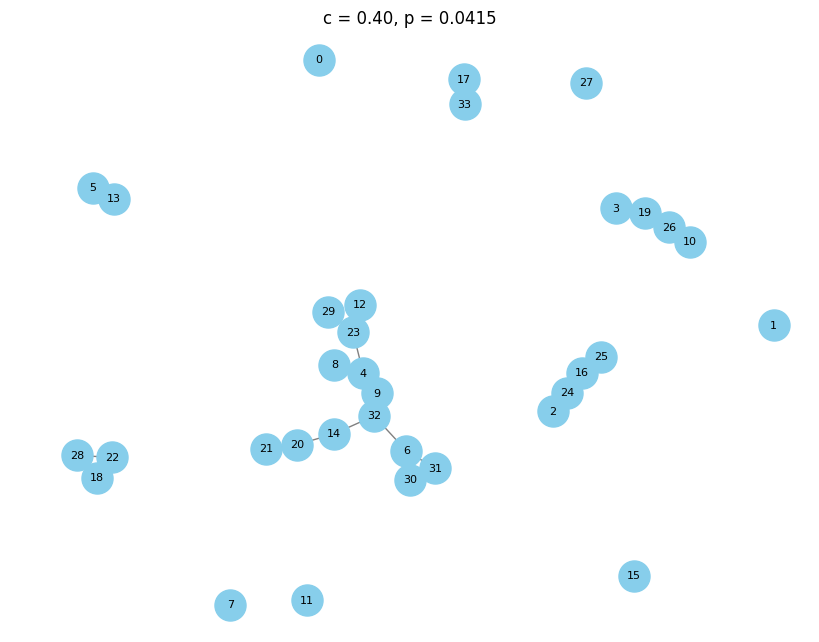

0: {'number of nodes': 34}
1: {'number of edges': 23}
2: {'density': 0.04}
3: {'is connected': False}
4: {"contains a 'giant component'": False}
5: {'number of connected components': 12}
6: {'list of component sizes (decending)': [13, 4, 4, 3, 2, 2, 1, 1, 1, 1, 1, 1]}
7: {'largest component size': 13}
8: {'largest component fraction': 0.38235294117647056}


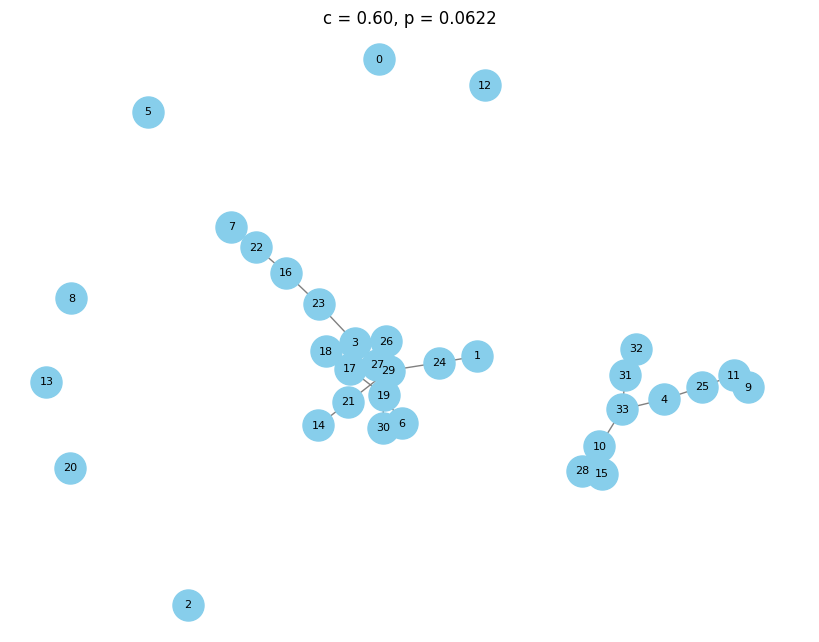

0: {'number of nodes': 34}
1: {'number of edges': 31}
2: {'density': 0.06}
3: {'is connected': False}
4: {"contains a 'giant component'": True}
5: {'number of connected components': 9}
6: {'list of component sizes (decending)': [17, 10, 1, 1, 1, 1, 1, 1, 1]}
7: {'largest component size': 17}
8: {'largest component fraction': 0.5}


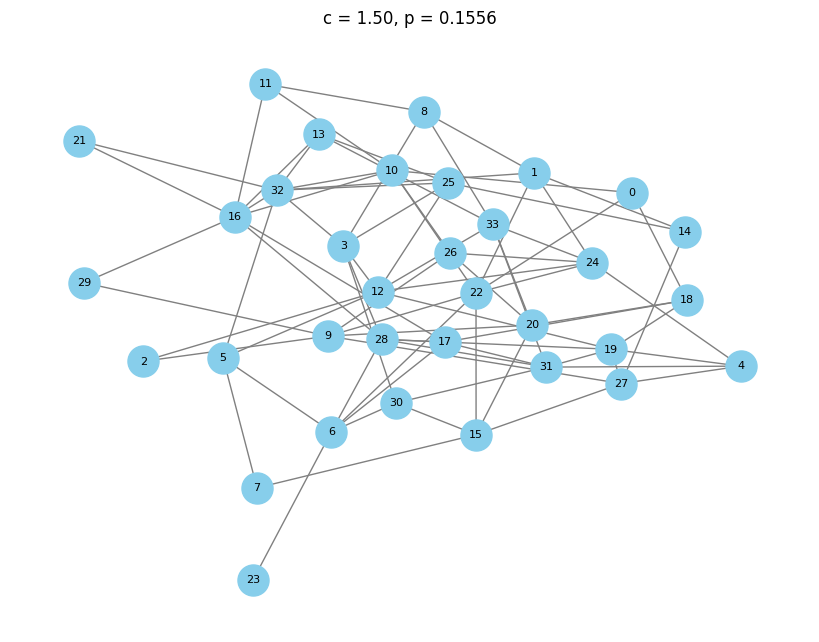

0: {'number of nodes': 34}
1: {'number of edges': 80}
2: {'density': 0.14}
3: {'is connected': True}
4: {"contains a 'giant component'": True}
5: {'number of connected components': 1}
6: {'list of component sizes (decending)': [34]}
7: {'largest component size': 34}
8: {'largest component fraction': 1.0}


In [42]:
import math
import random

# Assign n with number of nodes from the karate graph we calculated earlier (n = 34)
n = num_of_nodes

# Create 3 graphs with 34 nodes
G1 = nx.Graph()
G1.add_nodes_from(range(n)) # add nodes 0 through 33
G2 = nx.Graph()
G2.add_nodes_from(range(n))
G3 = nx.Graph()
G3.add_nodes_from(range(n))

# Assign c values to respective graphs
graph_c_values = {G1: 0.4, G2: 0.6, G3: 1.5}

# Assign edges using probability formula p = c * ln(n) / n, from class
# We need to randomize a value at every pair of nodes
# p is the probability of the pair of nodes having an edge
# So we need the random value to be smaller than the corresponding p value

# Calculate p for G1, and loop through node pairs (u,v)
for graph, c in graph_c_values.items():
    p = calculate_p(c,n)
    for u in range(n):
        for v in range(u + 1, n):
            if random.random() < p:
                graph.add_edge(u, v)

    # Draw the graph
    draw_graph(graph, c, p)

    # Display all graph's info
    graph_inf = graph_info(graph)
    for name, value in graph_inf.items():
      print(f"{name}: {value}")

### **Conceptual Questions** (Answer in Comments or Markdown)

1. For which values of `c` does a giant component appear?

2. How does increasing `c` affect connectivity and component sizes?

3. How do your observations compare with the Giant Component Theorem discussed in lecture?

1. Giant component appear for c values = 0.60 and 1.50.
2. Incrreasing c value will increase the chance of connectivity by decreasing the number of connected components and increasing the connected component's size.
3.